In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import densenet121
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
torch.cuda.is_available()

True

In [2]:
import h5py
# save('Data2/data.mat', 'total_recon_curr', 'total_recon_next','total_lambda','img','N','-v7.3');
with h5py.File('Data/data.mat', 'r') as f:
    print(list(f.keys()))  # see variables inside
    
    # example: load a dataset
    N = f['N'][:]
    img_truth = f['img'][:]
    total_freq_power = f['total_recon_curr'][:]
    # total_lambda = f['total_lambda'][:] #not needed
    total_recon = f['total_recon'][:]
    total_residual = f['total_residual'][:]
print(total_freq_power.shape)
print(total_recon.shape)
print(total_residual.shape)

['N', 'img', 'total_freq_power', 'total_lambda', 'total_recon', 'total_residual']
(171900, 64, 64)
(171900, 64, 64)
(171900, 64, 64)


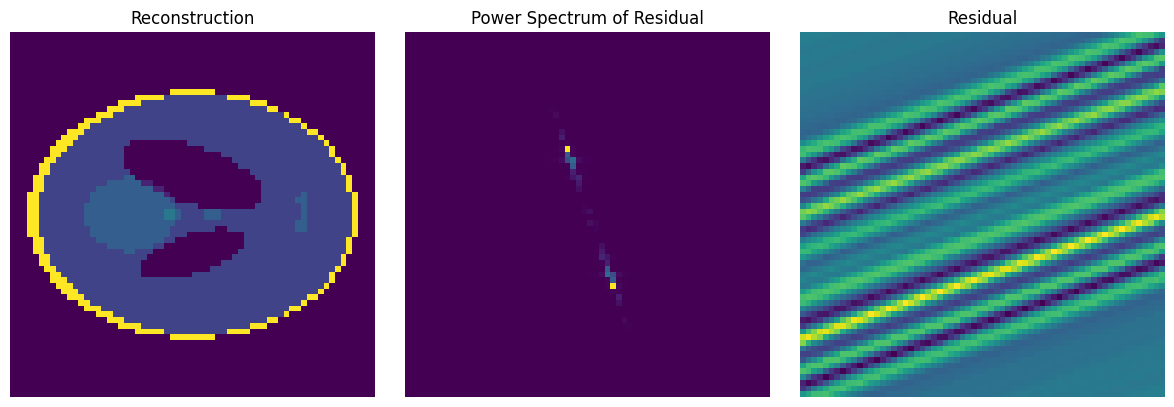

In [5]:
# verifying data import
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(total_recon[-1, :, :])
axes[0].set_title("Reconstruction")
axes[0].axis("off")

axes[1].imshow(total_freq_power[-1, :, :])
axes[1].set_title("Power Spectrum of Residual")
axes[1].axis("off")

axes[2].imshow(total_residual[-1, :, :])
axes[2].set_title("Residual")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
from recon_dataset import ReconDataset
from torch.utils.data import DataLoader
        
dataset = ReconDataset(
    total_recon,
    total_residual,
    total_freq_power,
    img_truth
)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)       

In [6]:
# use this for current reconstruction img
class DenseNetBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        model = densenet121(pretrained=pretrained)

        # remove classifier
        self.features = model.features

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)     # (B, C, H, W)
        x = nn.functional.relu(x, inplace=True)
        x = self.pool(x)        # (B, C, 1, 1)
        return x.view(x.size(0), -1)
# this output is of size (BATCH, 1024)

In [7]:
# use this for the residual
class Residual1DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        # x: (B, 64, 64) → pick projection axis
        x = x.mean(dim=1)  # or select projection direction
        x = x.unsqueeze(1)  # (B, 1, 64)
        return self.net(x).squeeze(-1)
# this output is of size (BATCH,64)

In [8]:
# use this for FT domain of the residual
class FFT2DCNN(nn.Module):
    def __init__(self, base=32):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, base, 3, padding=1),
            nn.BatchNorm2d(base),
            nn.ReLU(),

            nn.Conv2d(base, base*2, 3, padding=1),
            nn.BatchNorm2d(base*2),
            nn.ReLU(),

            nn.Conv2d(base*2, base*2, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = torch.log1p(torch.abs(x))   # IMPORTANT for FFT stability
        x = self.net(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)
# this output is of size (BATCH,64)

In [17]:
# fusion model
class FusionModule(nn.Module):
    # def __init__(self, d1=1024, d2=64, d3=64, d=128, hidden=256, out_dim=128):
    def __init__(self, d1=1024, d3=64, d=128, hidden=256, out_dim=128):
        super().__init__()

        # --- modality projection ---
        self.refine1 = nn.Linear(d1, d)
        # self.refine2 = nn.Linear(d2, d) # using cnn
        # self.refine2 = nn.Linear(d1, d) # using unnet
        self.refine3 = nn.Linear(d3, d)

        # --- gating network ---
        self.gate = nn.Sequential(
            nn.Linear(2 * d, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Softmax(dim=1)
        )

        # --- joint representation ---
        self.fc = nn.Sequential(
            # nn.Linear(3 * d, hidden),
            nn.Linear(2 * d, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        # --- final embedding ---
        self.out = nn.Linear(hidden + d, out_dim)

    # def forward(self, f1, f2, f3):
    def forward(self, f1, f3):

        # 1. project to shared space
        f1 = self.refine1(f1)  # (B,128)
        # f2 = self.refine2(f2)  # (B,128)
        f3 = self.refine3(f3)  # (B,128)

        # 2. concatenate
        # x = torch.cat([f1, f2, f3], dim=1)  # (B,384)
        x = torch.cat([f1, f3], dim=1)  # (B,384)

        # 3. gating weights
        w = self.gate(x)  # (B,3)

        # 4. weighted fusion
        fused = (
            w[:, 0:1] * f1 +
            w[:, 1:2] * f3
            # w[:, 1:2] * f2 +
            # w[:, 2:3] * f3
        )  # (B,128)

        # 5. joint nonlinear embedding
        h = self.fc(x)  # (B,256)

        # 6. final embedding
        out = self.out(torch.cat([h, fused], dim=1))  # (B,128)

        return out

In [18]:
class MultiModalNet(nn.Module):
    def __init__(self, K=3):
        super().__init__()

        self.K = K

        self.img_branch = DenseNetBackbone()
        # self.res_branch = DenseNetBackbone()
        self.fft_branch = FFT2DCNN()

        self.fusion = FusionModule(
            d1=1024,
            # d2=1024,
            d3=64,
            d=128,
            hidden=256,
            out_dim=128
        )

        self.regressor = nn.Linear(128, 1)

    def forward(self, x_img, x_res_init, x_fft, x_truth):

        x = x_img

        r0 = torch.mean((x_truth - x_img) ** 2)
        loss = 0.0

        for _ in range(self.K):

            # residual direction (consistent signal)
            x_res = x_res_init

            # features
            f1 = self.img_branch(x.repeat(1, 3, 1, 1))
            # f2 = self.res_branch(x_res.repeat(1, 3, 1, 1))
            f3 = self.fft_branch(x_fft)

            # normalization (good, keep)
            f1 = f1 / (f1.norm(dim=1, keepdim=True) + 1e-8)
            # f2 = f2 / (f2.norm(dim=1, keepdim=True) + 1e-8)
            f3 = f3 / (f3.norm(dim=1, keepdim=True) + 1e-8)

            # fused = self.fusion(f1, f2, f3)
            fused = self.fusion(f1, f3)

            lam = self.regressor(fused)

            # stable λ parameterization
            lam = torch.sigmoid(lam / 2.0)
            lam = 1e-4 + (2.0 - 1e-4) * lam
            lam = lam.view(-1, 1, 1, 1)

            # update step
            x = x + lam * x_res

            # trajectory loss
            loss = loss + F.mse_loss(x, x_truth)

            # convergence pressure
            r = torch.mean((x_truth - x) ** 2)
            loss = loss + 0.1 * (r / (r0 + 1e-8))

        return loss, x, lam

In [19]:
# device = torch.device("cpu")
# device = torch.device("mps")
device = torch.device("cuda")

In [20]:
model = MultiModalNet(K=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

EPOCHS = 10
print_every = 200

for epoch in range(EPOCHS):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for i, (x_img, x_res, x_fft, x_truth) in enumerate(pbar):

        x_img = x_img.to(device)
        x_res = x_res.to(device)
        x_fft = x_fft.to(device)
        x_truth = x_truth.to(device)

        loss, x_final, lam = model(x_img, x_res, x_fft, x_truth)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pbar.set_postfix(loss=loss.item(), lam=lam.mean().item())

        if i % print_every == 0:
            print(f"\nBatch [{i}/{len(loader)}] Loss: {loss.item():.6f}")

            # SAFE gradient logging
            if lam.grad is not None:
                print("λ mean:", lam.mean().item())

    print(f"===> Epoch {epoch+1} Avg Loss: {running_loss/len(loader):.6f}")

Epoch 1/10:   0%|                                                       | 0/10744 [00:00<?, ?it/s, lam=0.988, loss=0.3]C:\Users\clin4\AppData\Local\Temp\ipykernel_25376\2314961205.py:33: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  if lam.grad is not None:
Epoch 1/10:   0%|                                             | 1/10744 [00:00<2:52:32,  1.04it/s, lam=0.988, loss=0.3]


Batch [0/10744] Loss: 0.299609


Epoch 1/10:   2%|▊                                          | 201/10744 [00:49<42:13,  4.16it/s, lam=0.662, loss=0.296]


Batch [200/10744] Loss: 0.296432


Epoch 1/10:   4%|█▌                                         | 401/10744 [01:37<41:31,  4.15it/s, lam=0.593, loss=0.297]

...


Batch [10400/10744] Loss: 0.297892


Epoch 10/10:  99%|██████████████████████████████████████▍| 10601/10744 [42:28<00:35,  4.07it/s, lam=0.0403, loss=0.297]


Batch [10600/10744] Loss: 0.297001


Epoch 10/10: 100%|████████████████████████████████████████| 10744/10744 [43:02<00:00,  4.16it/s, lam=0.102, loss=0.288]

===> Epoch 10 Avg Loss: 0.291881
